In [49]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import importlib
import src.hito_03_eda_helpers as hito_03_eda_helpers
importlib.reload(hito_03_eda_helpers)
from src.hito_03_eda_helpers import identificar_valores_nulos_y_tipos, graficar_distribuciones, analisis_correlacion, detectar_anomalias_boxplots, graficar_dispersion_mapa, graficar_mapa_densidad

# Configuración de estilo para visualizaciones
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

# Carpeta de salida para gráficos
OUTPUT_PLOTS_DIR = "outputs/eda_plots"
os.makedirs(OUTPUT_PLOTS_DIR, exist_ok=True)

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


In [37]:
CSV_PATH_SEVILLA_PIXELS = "../datasets/raw/sevilla_dataset_pixels.csv"
df_sevilla_pixels = pd.read_csv(CSV_PATH_SEVILLA_PIXELS)

print(f"Dataset cargado: {CSV_PATH_SEVILLA_PIXELS}")
print(f"Dimensiones pixels: {df_sevilla_pixels.shape[0]:,} filas × {df_sevilla_pixels.shape[1]} columnas")


CSV_PATH_EDIFICIOS = "../datasets/raw/edificios_sevilla.csv"
df_edificios_sevilla = pd.read_csv(CSV_PATH_EDIFICIOS)

print(f"Dataset cargado: {CSV_PATH_EDIFICIOS}")
print(f"Dimensiones edificios: {df_edificios_sevilla.shape[0]:,} filas × {df_edificios_sevilla.shape[1]} columnas")


CSV_PATH_CARRETERAS = "../datasets/raw/carreteras_sevilla.csv"
df_carreteras_sevilla = pd.read_csv(CSV_PATH_CARRETERAS)

print(f"Dataset cargado: {CSV_PATH_CARRETERAS}")
print(f"Dimensiones carreteras: {df_carreteras_sevilla.shape[0]:,} filas × {df_carreteras_sevilla.shape[1]} columnas")

CSV_PATH_ARBOLADO = "../datasets/raw/arbolado_sevilla.csv"
df_arbolado_sevilla = pd.read_csv(CSV_PATH_ARBOLADO)

print(f"Dataset cargado: {CSV_PATH_ARBOLADO}")
print(f"Dimensiones arbolado: {df_arbolado_sevilla.shape[0]:,} filas × {df_arbolado_sevilla.shape[1]} columnas")

Dataset cargado: ../datasets/raw/sevilla_dataset_pixels.csv
Dimensiones pixels: 484,356 filas × 7 columnas
Dataset cargado: ../datasets/raw/edificios_sevilla.csv
Dimensiones edificios: 29,960 filas × 4 columnas
Dataset cargado: ../datasets/raw/carreteras_sevilla.csv
Dimensiones carreteras: 3,182 filas × 5 columnas
Dataset cargado: ../datasets/raw/arbolado_sevilla.csv
Dimensiones arbolado: 10,000 filas × 4 columnas


Datos satelitales

In [50]:
print("=== 1. IDENTIFICACIÓN GENERAL ===")
identificar_valores_nulos_y_tipos(df_sevilla_pixels)

=== 1. IDENTIFICACIÓN GENERAL ===
--- Información del Dataset ---
<class 'pandas.DataFrame'>
RangeIndex: 484356 entries, 0 to 484355
Data columns (total 7 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   Longitude   484356 non-null  float64
 1   Latitude    484356 non-null  float64
 2   NDVI        484356 non-null  float64
 3   NDBI        484356 non-null  float64
 4   Albedo      484356 non-null  float64
 5   D2W_meters  484356 non-null  float64
 6   LST_Target  484356 non-null  float64
dtypes: float64(7)
memory usage: 25.9 MB
None

--- Valores Nulos por Columna ---
Longitude     0
Latitude      0
NDVI          0
NDBI          0
Albedo        0
D2W_meters    0
LST_Target    0
dtype: int64

--- Estadísticas Descriptivas ---


,Longitude,Latitude,NDVI,NDBI,Albedo,D2W_meters,LST_Target
count,484356.000000,484356.000000,484356.000000,484356.000000,484356.000000,484356.000000,484356.000000
mean,-5.964993,37.389948,0.228368,0.027242,0.214880,205.498991,47.493737
std,0.037550,0.034697,0.221364,0.142571,0.063660,192.415219,4.003924
min,-6.029941,37.329941,-1.000000,-0.630200,0.002293,0.000000,29.594249
25%,-5.997467,37.359945,0.095436,-0.038156,0.179143,70.710678,45.500005
50%,-5.964993,37.389948,0.178871,0.049435,0.210855,142.126704,47.769570
75%,-5.932519,37.419952,0.331392,0.115421,0.244974,281.602557,50.254471
max,-5.900045,37.449956,0.927826,1.000000,0.808436,1368.831619,58.939659



=== 2. DISTRIBUCIONES (HISTOGRAMAS Y BARRAS) ===


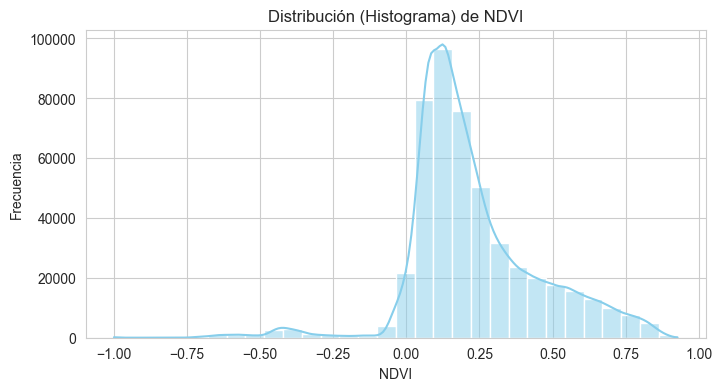

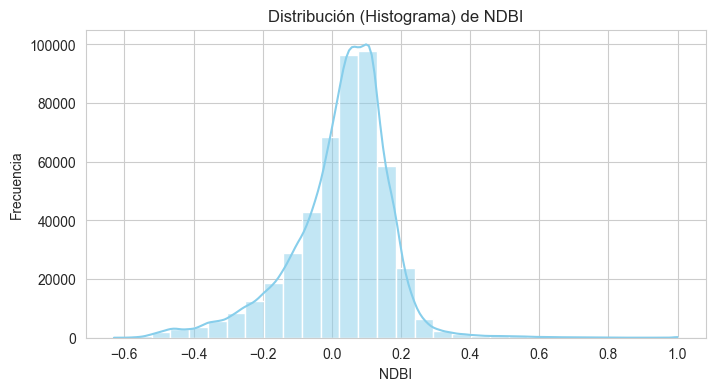

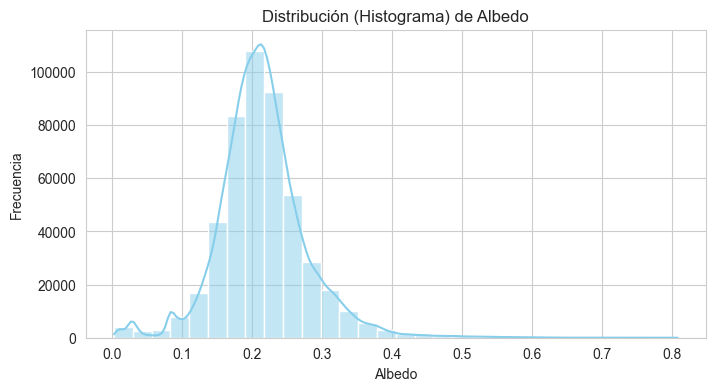

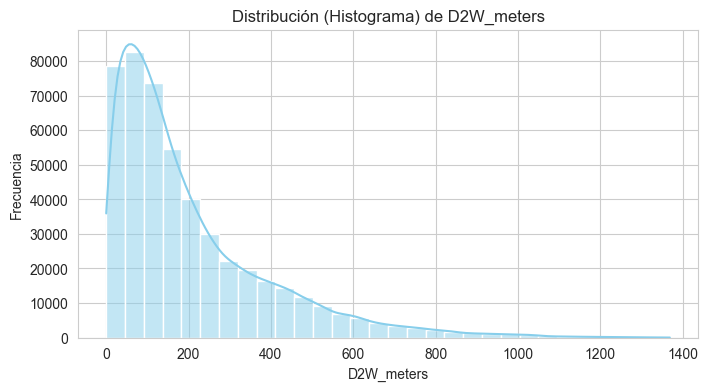

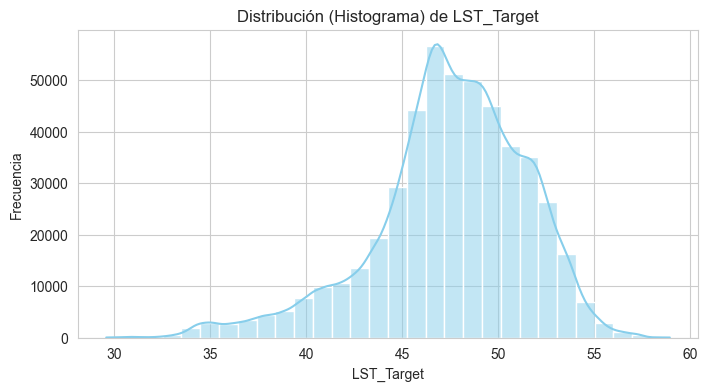


=== 3. ANOMALÍAS Y VALORES ATÍPICOS (BOXPLOTS) ===


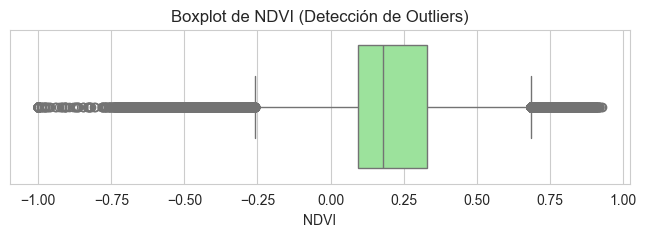

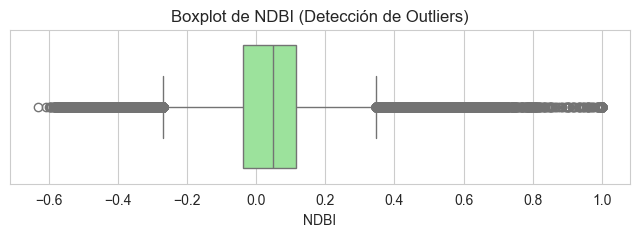

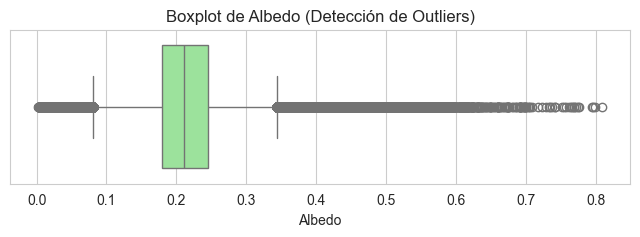

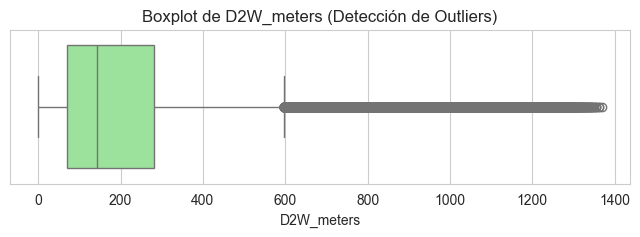

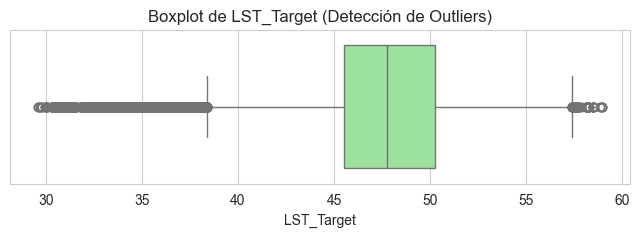


=== 4. DIAGRAMA DE DISPERSIÓN ===


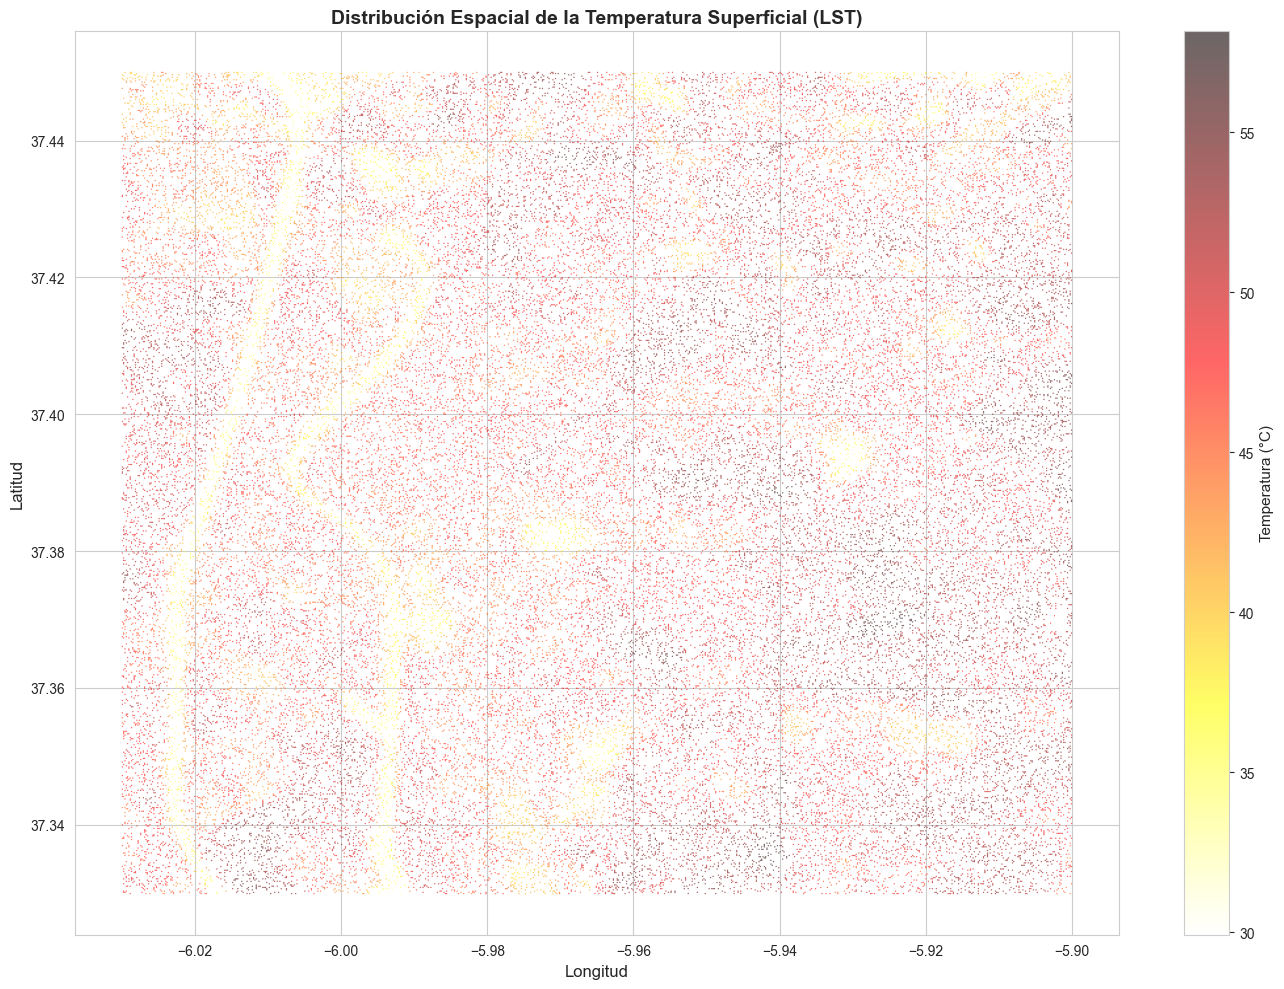


=== 5. ANÁLISIS DE CORRELACIÓN ===


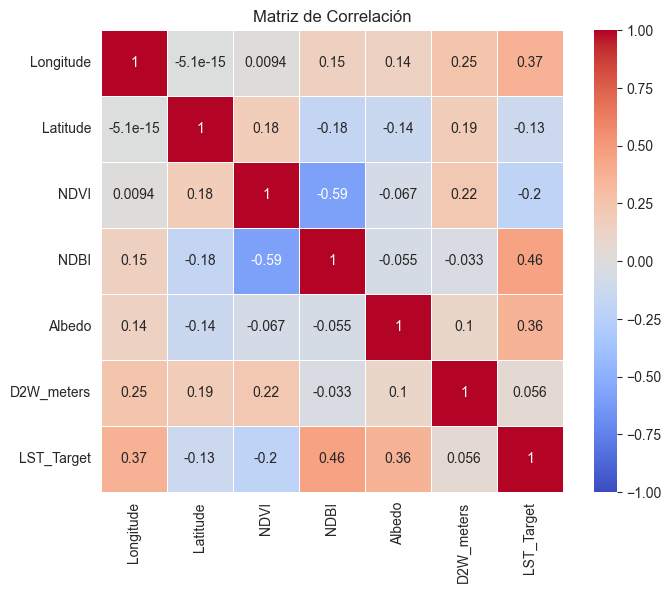

In [45]:
cols_numericas = ['Longitude', 'Latitude', 'NDVI', "NDBI", "Albedo", "D2W_meters", "LST_Target"]
cols_categoricas = []
ignorar_para_distribucion = ['Latitude', 'Longitude']

print("\n=== 2. DISTRIBUCIONES (HISTOGRAMAS Y BARRAS) ===")
graficar_distribuciones(df_sevilla_pixels, cols_numericas, cols_categoricas, ignorar_para_distribucion)

print("\n=== 3. ANOMALÍAS Y VALORES ATÍPICOS (BOXPLOTS) ===")
detectar_anomalias_boxplots(df_sevilla_pixels, cols_numericas, ignorar_para_distribucion)

print("\n=== 4. DIAGRAMA DE DISPERSIÓN ===")
graficar_mapa_densidad(
    df=df_sevilla_pixels
)

print("\n=== 5. ANÁLISIS DE CORRELACIÓN ===")
analisis_correlacion(df_sevilla_pixels)

Edificios

In [24]:
print("=== 1. IDENTIFICACIÓN GENERAL ===")
identificar_valores_nulos_y_tipos(df_edificios_sevilla)

=== 1. IDENTIFICACIÓN GENERAL ===
--- Información del Dataset ---
<class 'pandas.DataFrame'>
RangeIndex: 29960 entries, 0 to 29959
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id_edificio      29960 non-null  int64  
 1   latitud          29960 non-null  float64
 2   longitud         29960 non-null  float64
 3   altura_estimada  29960 non-null  float64
dtypes: float64(3), int64(1)
memory usage: 936.4 KB
None

--- Valores Nulos por Columna ---
id_edificio        0
latitud            0
longitud           0
altura_estimada    0
dtype: int64

--- Estadísticas Descriptivas ---


,id_edificio,latitud,longitud,altura_estimada
count,2.996000e+04,29960.000000,29960.000000,29960.000000
mean,6.120327e+08,37.389656,-5.985148,8.571018
std,3.692052e+08,0.018760,0.021070,107.388175
min,5.107100e+04,37.329436,-6.030905,0.000000
25%,3.813077e+08,37.379291,-6.000263,6.000000
50%,5.820433e+08,37.388272,-5.989310,6.000000
75%,7.610766e+08,37.400367,-5.975879,6.000000
max,1.526530e+09,37.448815,-5.899298,18462.000000



=== 2. DISTRIBUCIONES (HISTOGRAMAS Y BARRAS) ===


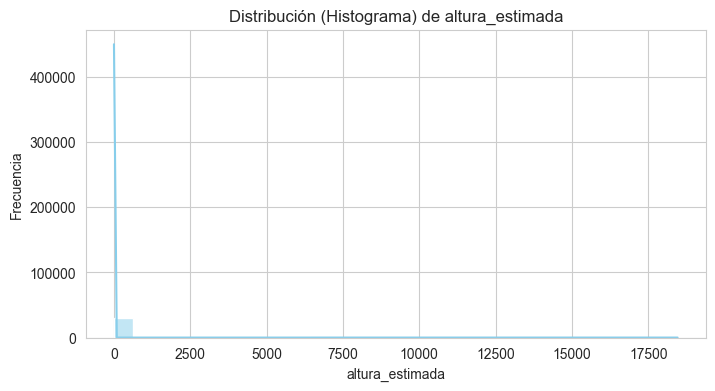


=== 3. ANOMALÍAS Y VALORES ATÍPICOS (BOXPLOTS) ===


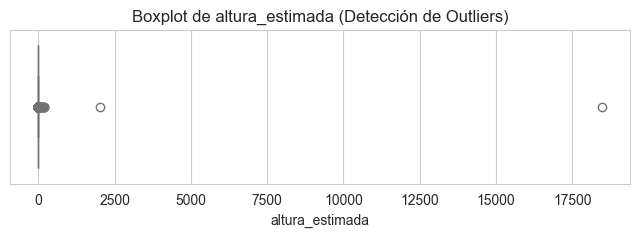


=== 4. DIAGRAMA DE DISPERSIÓN ===



=== 5. ANÁLISIS DE CORRELACIÓN ===

=== No tiene sentido ya que las variables numericas son la latitud y longitud y el id ===


In [26]:
cols_numericas = ['latitud', 'longitud', 'altura_estimada']
cols_categoricas = []
ignorar_para_distribucion = ['latitud', 'longitud', 'id_edificio']

print("\n=== 2. DISTRIBUCIONES (HISTOGRAMAS Y BARRAS) ===")
graficar_distribuciones(df_edificios_sevilla, cols_numericas, cols_categoricas, ignorar_para_distribucion)

print("\n=== 3. ANOMALÍAS Y VALORES ATÍPICOS (BOXPLOTS) ===")
detectar_anomalias_boxplots(df_edificios_sevilla, cols_numericas, ignorar_para_distribucion)

print("\n=== 4. DIAGRAMA DE DISPERSIÓN ===")
graficar_dispersion_mapa(
    df=df_edificios_sevilla, 
    col_lat='latitud', 
    col_lon='longitud', 
    col_categoria=None
)

print("\n=== 5. ANÁLISIS DE CORRELACIÓN ===")
print("\n=== No tiene sentido ya que las variables numericas son la latitud y longitud y el id ===")

Carreteras de sevilla

In [22]:

print("=== 1. IDENTIFICACIÓN GENERAL ===")
identificar_valores_nulos_y_tipos(df_carreteras_sevilla)

=== 1. IDENTIFICACIÓN GENERAL ===
--- Información del Dataset ---
<class 'pandas.DataFrame'>
RangeIndex: 3182 entries, 0 to 3181
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id_via    3182 non-null   int64  
 1   tipo      3182 non-null   str    
 2   nombre    3182 non-null   str    
 3   latitud   3182 non-null   float64
 4   longitud  3182 non-null   float64
dtypes: float64(2), int64(1), str(2)
memory usage: 124.4 KB
None

--- Valores Nulos por Columna ---
id_via      0
tipo        0
nombre      0
latitud     0
longitud    0
dtype: int64

--- Estadísticas Descriptivas ---


,id_via,tipo,nombre,latitud,longitud
count,3.182000e+03,3182,3182,3182.000000,3182.000000
unique,NaN,8,271,NaN,NaN
top,NaN,primary,Sin nombre,NaN,NaN
freq,NaN,1464,995,NaN,NaN
mean,4.323284e+08,NaN,NaN,37.382081,-5.974520
std,4.441655e+08,NaN,NaN,0.025168,0.028129
min,1.023319e+07,NaN,NaN,37.326527,-6.032144
25%,5.772245e+07,NaN,NaN,37.366621,-5.993444
50%,2.578738e+08,NaN,NaN,37.382334,-5.976428
75%,6.411894e+08,NaN,NaN,37.400045,-5.954427



=== 2. DISTRIBUCIONES (HISTOGRAMAS Y BARRAS) ===


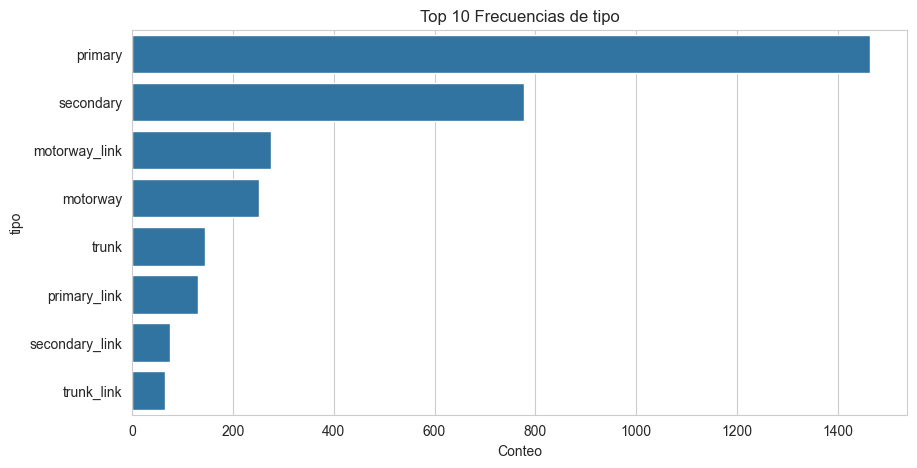


=== 3. ANOMALÍAS Y VALORES ATÍPICOS (BOXPLOTS) ===

=== 4. DIAGRAMA DE DISPERSIÓN ===



=== 5. ANÁLISIS DE CORRELACIÓN ===

=== No tiene sentido ya que las variables numericas son la latitud y longitud y el id ===


In [23]:
cols_numericas = ['latitud', 'longitud']
cols_categoricas = ['tipo']
ignorar_para_distribucion = ['latitud', 'longitud', 'id_via']

print("\n=== 2. DISTRIBUCIONES (HISTOGRAMAS Y BARRAS) ===")
graficar_distribuciones(df_carreteras_sevilla, cols_numericas, cols_categoricas, ignorar_para_distribucion)

print("\n=== 3. ANOMALÍAS Y VALORES ATÍPICOS (BOXPLOTS) ===")
detectar_anomalias_boxplots(df_carreteras_sevilla, cols_numericas, ignorar_para_distribucion)

print("\n=== 4. DIAGRAMA DE DISPERSIÓN ===")
graficar_dispersion_mapa(
    df=df_carreteras_sevilla, 
    col_lat='latitud', 
    col_lon='longitud', 
    col_categoria=None
)

print("\n=== 5. ANÁLISIS DE CORRELACIÓN ===")
print("\n=== No tiene sentido ya que las variables numericas son la latitud y longitud y el id ===")

Arbolado    

=== 1. IDENTIFICACIÓN GENERAL ===
--- Información del Dataset ---
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id_arbol  10000 non-null  int64  
 1   especie   10000 non-null  str    
 2   latitud   10000 non-null  float64
 3   longitud  10000 non-null  float64
dtypes: float64(2), int64(1), str(1)
memory usage: 312.6 KB
None

--- Valores Nulos por Columna ---
id_arbol    0
especie     0
latitud     0
longitud    0
dtype: int64

--- Estadísticas Descriptivas ---


,id_arbol,especie,latitud,longitud
count,10000.00000,10000,10000.000000,10000.000000
unique,NaN,5,NaN,NaN
top,NaN,Naranjo amargo,NaN,NaN
freq,NaN,3555,NaN,NaN
mean,5000.50000,NaN,37.390544,-5.964993
std,2886.89568,NaN,0.034715,0.037281
min,1.00000,NaN,37.330019,-6.029994
25%,2500.75000,NaN,37.360473,-5.997013
50%,5000.50000,NaN,37.390708,-5.964731
75%,7500.25000,NaN,37.420778,-5.933192



=== 2. DISTRIBUCIONES (HISTOGRAMAS Y BARRAS) ===


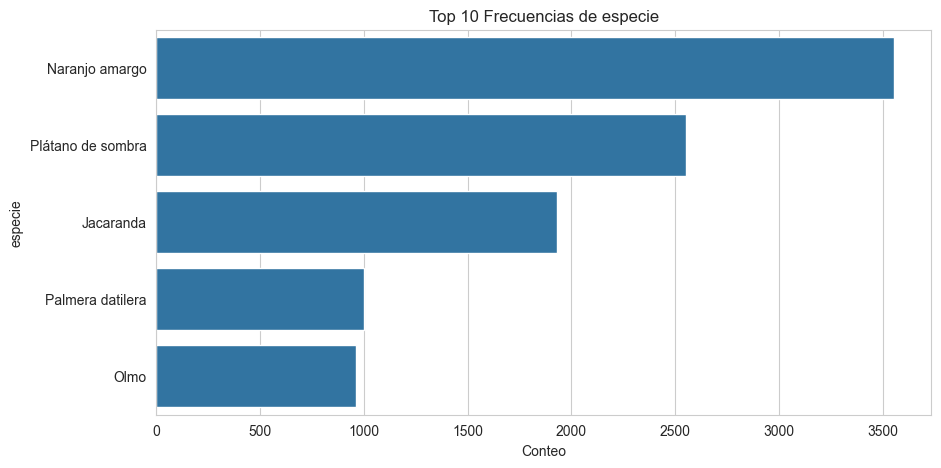


=== 3. ANOMALÍAS Y VALORES ATÍPICOS (BOXPLOTS) ===

=== 4. DIAGRAMA DE DISPERSIÓN ===



=== 5. ANÁLISIS DE CORRELACIÓN ===

=== No tiene sentido ya que las variables numericas son la latitud y longitud y el id ===


In [19]:
cols_numericas = ['latitud', 'longitud']
cols_categoricas = ['especie']
ignorar_para_distribucion = ['latitud', 'longitud', 'id_arbol']

# 3. Ejecutar el pipeline de análisis usando las funciones

print("=== 1. IDENTIFICACIÓN GENERAL ===")
identificar_valores_nulos_y_tipos(df_arbolado_sevilla)

print("\n=== 2. DISTRIBUCIONES (HISTOGRAMAS Y BARRAS) ===")
graficar_distribuciones(df_arbolado_sevilla, cols_numericas, cols_categoricas, ignorar_para_distribucion)

print("\n=== 3. ANOMALÍAS Y VALORES ATÍPICOS (BOXPLOTS) ===")
detectar_anomalias_boxplots(df_arbolado_sevilla, cols_numericas, ignorar_para_distribucion)

print("\n=== 4. DIAGRAMA DE DISPERSIÓN ===")
graficar_dispersion_mapa(
    df=df_arbolado_sevilla, 
    col_lat='latitud', 
    col_lon='longitud', 
    col_categoria='especie'
)

print("\n=== 5. ANÁLISIS DE CORRELACIÓN ===")
print("\n=== No tiene sentido ya que las variables numericas son la latitud y longitud y el id ===")
